### kNN Regression 으로 50cm 생선의 무게를 예측해보자

In [1]:
import numpy as np

In [2]:
fish_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
fish_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 
     1000.0, 1000.0]
     )

In [3]:
from sklearn.model_selection import train_test_split

In [ ]:
train_input, test_input, train_target, test_target = \
    train_test_split(
        fish_length,
        fish_weight,
        random_state=42
    )

In [5]:
# 1열로 구성된 배열로 재구성
train_input = train_input.reshape(-1,1)
test_input = test_input.reshape(-1,1)

#### kNN Regression Model

In [6]:
from sklearn.neighbors import KNeighborsRegressor

In [7]:
# 이웃의 갯수를 3으로 선택 (14 파일에서 3이 젤 좋았음.)
knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


#### 길이가 50cm 인 생선의 무게를 예측

In [8]:
knr.predict([[50]])

array([1033.33333333])

#### 기존 데이터로 무게 확인

In [12]:
for i, v in list(enumerate(train_target)):    # enumerate : 열거. 순서까지 보여줌.
    # print(i, v)   # i : index 번호, v : train_target 값
    if v == train_target.max():
        print(train_input[i], v)

[43.] 1100.0
[42.] 1100.0


> 기존 데이터에서는 길이가 42, 43 cm 인 생선의 무게가 1100 이었음. 하지만 50cm 인 경우에 1033 으로 나옴.   << 이상함

#### 산점도로 이웃을 구해서 확인해보자

In [13]:
import matplotlib.pyplot as plt

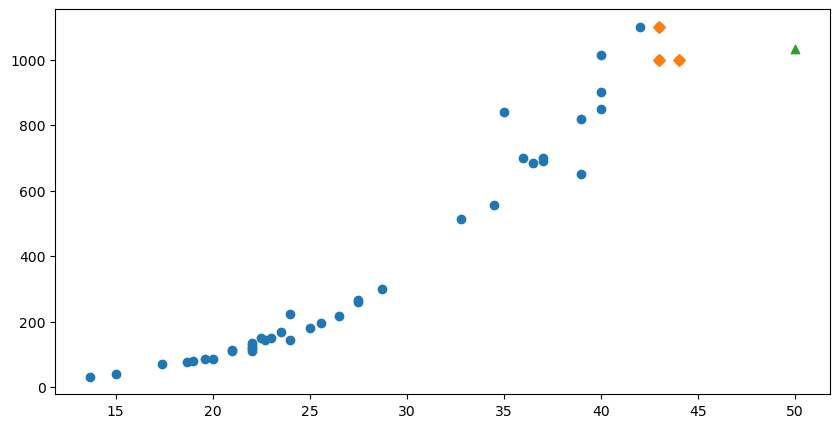

In [20]:
# 50cm 인 생선의 이웃을 찾자
distance, indexes = knr.kneighbors([[50]])    ## 50cm 주변 이웃의 distance, index 참조.

# 훈련세트의 산점도
plt.figure(figsize=(10,5))
plt.scatter(
    train_input, train_target
)

# 이웃을 그리자
plt.scatter(
    train_input[indexes],    # 위에서 지정한 주변 이웃들을 나타내기 위함
    train_target[indexes], 
    marker='D'
)

plt.scatter(
    50, 1033,
    marker='^'
)

plt.show()

In [22]:
# 이웃들의 평균값 계산
np.mean(train_target[indexes])    # 답을 평균값으로 찾는 구나 를 알 수 있음

np.float64(1033.3333333333333)

#### 길이가 100cm 인 생선의 무게를 예측해보자

In [23]:
#  길이가 100cm 인 생선의 무게
knr.predict([[100]])

array([1033.33333333])

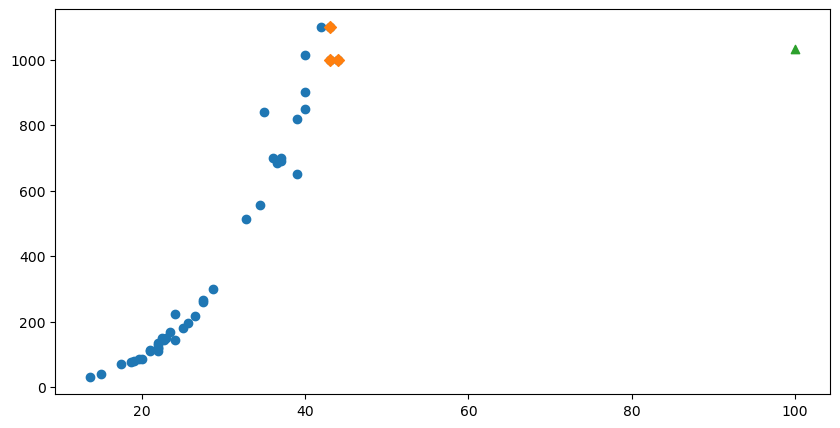

In [25]:
# 시각화로 확인
# 100cm 인 생선의 이웃을 찾자
distance, indexes = knr.kneighbors([[100]])    ## 100cm 주변 이웃의 distance, index 참조.

# 훈련세트의 산점도
plt.figure(figsize=(10,5))
plt.scatter(
    train_input, train_target
)

# 이웃을 그리자
plt.scatter(
    train_input[indexes],    # 위에서 지정한 주변 이웃들을 나타내기 위함
    train_target[indexes], 
    marker='D'
)

plt.scatter(
    100, 1033,
    marker='^'
)

plt.show()

> kNN Regression 은 주변 이웃 값들의 평균을 구하는 것이므로 학습한 데이터의 범위를 벗어나게 되면 사용할 수 없다.

----
#### 선형 회귀(Linear Regression)
 : 직선이나 곡선의 함수 식 (방정식: y = ax + b) 을 이용하여 구하는 방식으로 로지스틱 회귀분석이나 인공신경망의 기초가 되었다.

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
# 좌표들로 선형 그래프 그려서 다음 값을 예측함.

# Model
lr = LinearRegression()

# 학습
lr.fit(train_input, train_target)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
# 50cm 생선의 무게에 대한 예측
lr.predict([[50]])
# 1241 로 나옴. 위에 kNN은 주변을 보고 예측해서 제대로 된 값이 안 나오지만 얘는 선형 그래프를 그려서 값을 예측할 수 있게 됨.

array([1241.83860323])

In [ ]:
# y=ax+b 에서 기울기와 절편 출력(Deep Learning 에서는 weight, bias 로 불림)
print(lr.coef_, lr.intercept_)  # coef_ : 기울기, intercept_ : 절편
# 기울기는 list([]) 로 나오는 데 이건 x가 여러개일 수 있기 때문에 기울기도 여러 개일 수 있음 (예_ax + bx + c)

[39.01714496] -709.0186449535477


In [32]:
39.01714496 * 50 - 709.0186449535477

1241.8386030464526

#### 산점도 그려보기

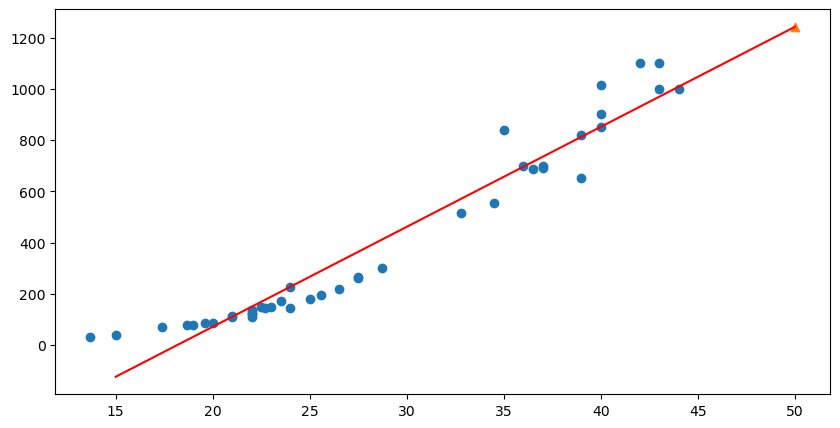

In [36]:
# 훈련세트의 산점도
plt.figure(figsize=(10, 5))
plt.scatter(train_input, train_target)

# 길이가 15 ~ 50 까지 1차방정식 그래프를 그려보기
plt.plot(
    [15, 50],
    [15*lr.coef_+lr.intercept_, 50*lr.coef_+lr.intercept_],
    c='red'
)

# 50 cm 생선
plt.scatter(50, 1241.8386030464526, marker='^')

plt.show()

> 산점도의 회귀선을 보니 길이가 작아지면 무게가 음수가 되어버림. 또, 절편이 음수임.    
제일 좋은 방법은 곡선형태로 이루어지면 정확할 거 같음.

----
#### 특성공학(Feature Engineering) 이 필요
##### 단순회귀 - 특성공학은 x
위에서 했던 선형을 단순회귀라고 함
##### 다항회귀 
y = ax + b -> y = ax^2 + bx + c
##### 다중회귀 
y = ax1 + ax2 +... + b

In [37]:
# Feature 를 제곱한 Column 을 생성하여 기존의 Column 에 붙인다.
train_poly = np.column_stack((train_input**2, train_input))
test_poly = np.column_stack((test_input**2, test_input))

In [39]:
print(train_poly.shape)
print(test_poly.shape)

(42, 2)
(14, 2)


In [40]:
# 모델 만들기
lr = LinearRegression()

In [41]:
# 훈련
lr.fit(train_poly, train_target)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
# 50cm 생선의 무게를 예측해보자
lr.predict([[50**2, 50]])

array([1573.98423528])

In [43]:
# 기울기와 절편을 구해보기
print(lr.coef_, lr.intercept_)

[  1.01433211 -21.55792498] 116.0502107827827


In [45]:
1.01433211* 50**2 -21.55792498 * 50 + 116.0502107827827

1573.9842367827825

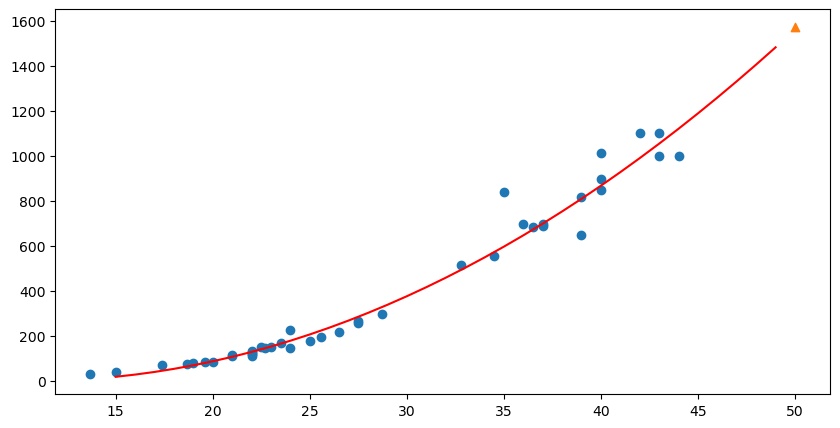

In [48]:
# 훈련세트의 산점도
plt.figure(figsize=(10, 5))
plt.scatter(train_input, train_target)

# 길이가 15 ~ 50 까지 1차방정식 그래프를 그려보기
point = np.arange(15, 50)
plt.plot(
    point,
    1.01 * point**2 - 21.6 * point + 116.05,
    c='red'
)

# 50 cm 생선
plt.scatter(50, 1574, marker='^')

plt.show()